In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import fit_3D_gan
from utils.loss_functions import recon_loss
from models.alzheimers_cure_2d import VAE
from models.alzheiminator_3d import Discriminator3D, Generator3D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


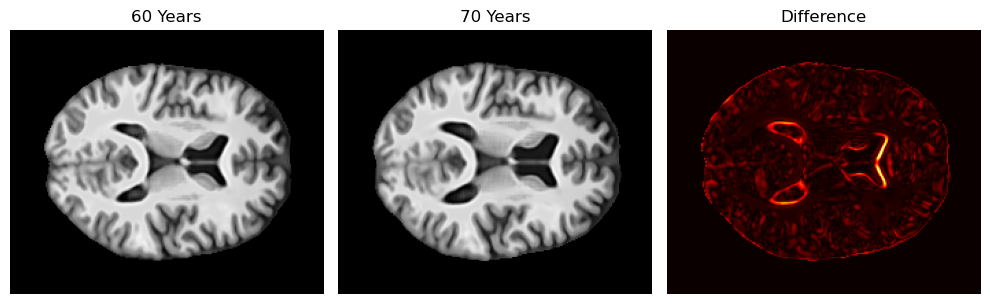

In [4]:
middle_h3 = data_loader.get_slice(training_pairs[100][0], index=90)
middle_h4 = data_loader.get_slice(training_pairs[100][1], index=90)

difference = np.abs(middle_h3 - middle_h4)
data_loader.display_slices([middle_h3, middle_h4, difference], ["60 Years", "70 Years", "Difference"], slice_colors=["gray", "gray", "hot"])

## Combined Dice + Volumetric Difference Loss

The `combined_dice_volume_loss` combines two complementary loss functions:
1. **Dice Loss**: Measures the overlap between predicted and target probability maps
2. **Volumetric Difference Loss**: Penalizes differences in total volume between predictions and targets

This is useful for 3D medical image segmentation/reconstruction tasks where both spatial overlap and volume preservation are important.

In [5]:
G = Generator3D(in_channels=1, out_channels=1).to(device)
G.load_state_dict(torch.load("out/mpgan_3d/3d_mpgan_model_G.pt"))
D = Discriminator3D(in_channels=1).to(device)
D.load_state_dict(torch.load("out/mpgan_3d/3d_mpgan_model_D.pt"))

<All keys matched successfully>

In [10]:
# Use with fit_3D
G, D, snapshots = fit_3D_gan(
    G=G,
    D=D,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    epochs=2001,
    lambda_recon=1.0,
    lambda_adv=0.005,
    save_every=200,
    print_every=100
)

[Iter 0] D_total=0.0033 G_total=0.0999 Recon=0.0821 AdvG=3.5596
Saved snapshot at iter 0
[Iter 100] D_total=0.0037 G_total=0.1073 Recon=0.0794 AdvG=5.5886
[Iter 200] D_total=0.0021 G_total=0.1079 Recon=0.0776 AdvG=6.0587
Saved snapshot at iter 200
[Iter 300] D_total=0.0019 G_total=0.1072 Recon=0.0760 AdvG=6.2382
[Iter 400] D_total=0.0018 G_total=0.1062 Recon=0.0747 AdvG=6.2989
Saved snapshot at iter 400
[Iter 500] D_total=0.0013 G_total=0.1067 Recon=0.0748 AdvG=6.3847
[Iter 600] D_total=0.0014 G_total=0.1087 Recon=0.0767 AdvG=6.3940
Saved snapshot at iter 600
[Iter 700] D_total=0.0010 G_total=0.1194 Recon=0.0865 AdvG=6.5697
[Iter 800] D_total=0.0010 G_total=0.1040 Recon=0.0713 AdvG=6.5433
Saved snapshot at iter 800
[Iter 900] D_total=0.0010 G_total=0.1043 Recon=0.0705 AdvG=6.7633
[Iter 1000] D_total=0.0018 G_total=0.0974 Recon=0.0667 AdvG=6.1380
Saved snapshot at iter 1000
[Iter 1100] D_total=0.0009 G_total=0.0995 Recon=0.0660 AdvG=6.7011
[Iter 1200] D_total=0.0010 G_total=0.1051 Recon

Displaying snapshot from pair 0


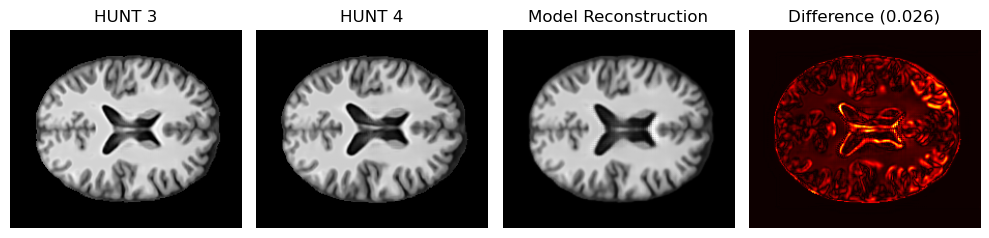

Displaying snapshot from pair 200


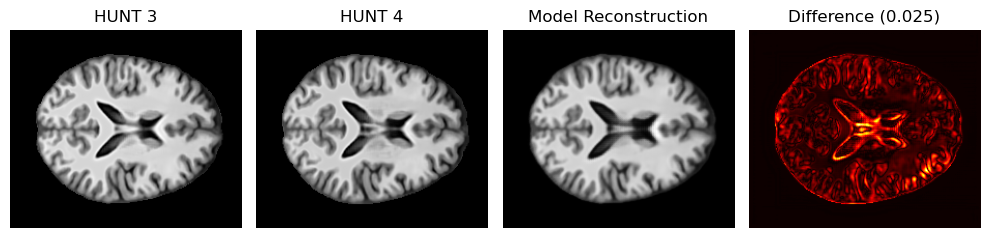

Displaying snapshot from pair 400


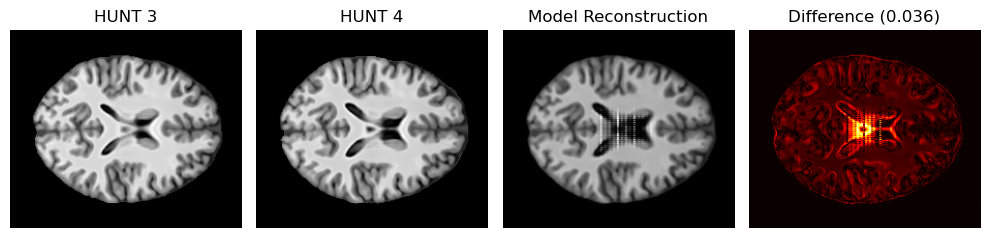

Displaying snapshot from pair 600


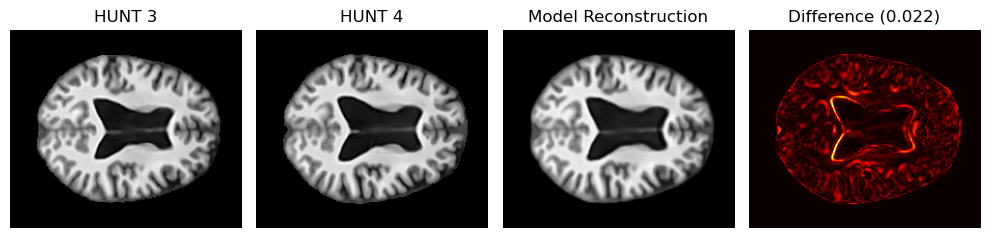

Displaying snapshot from pair 800


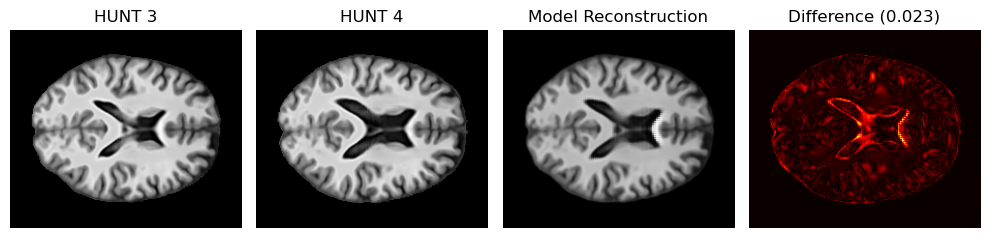

Displaying snapshot from pair 1000


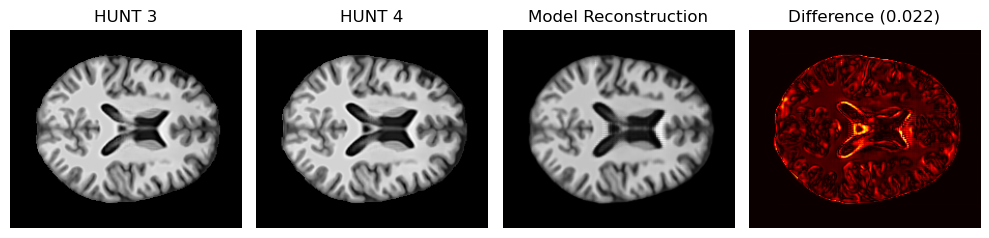

Displaying snapshot from pair 1200


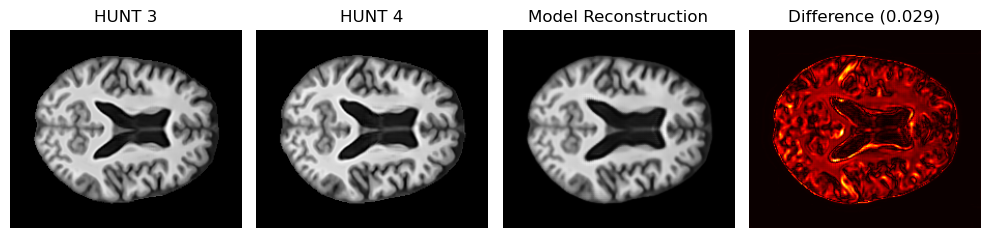

Displaying snapshot from pair 1400


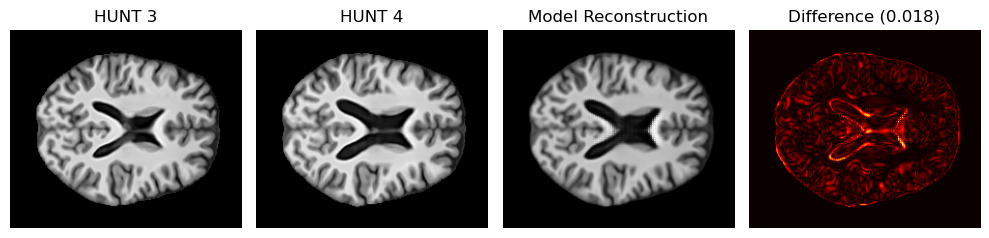

Displaying snapshot from pair 1600


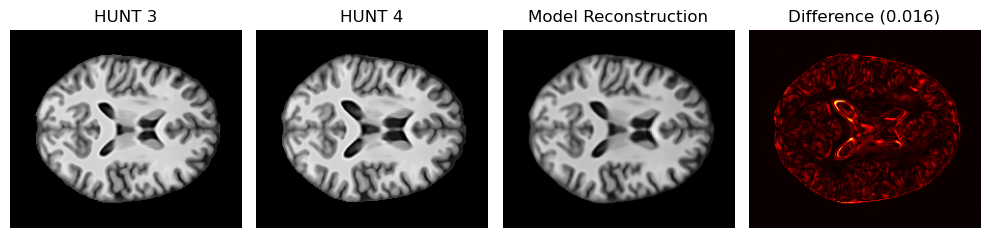

Displaying snapshot from pair 1800


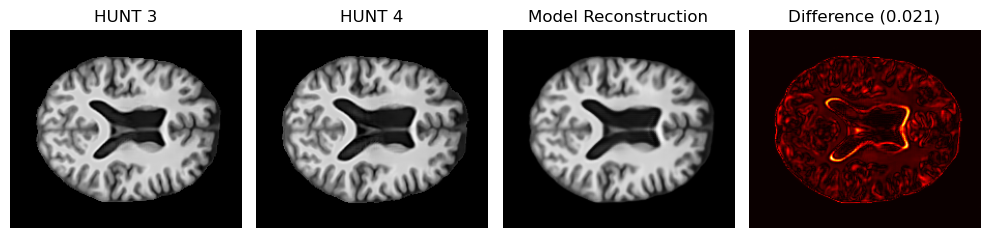

Displaying snapshot from pair 2000


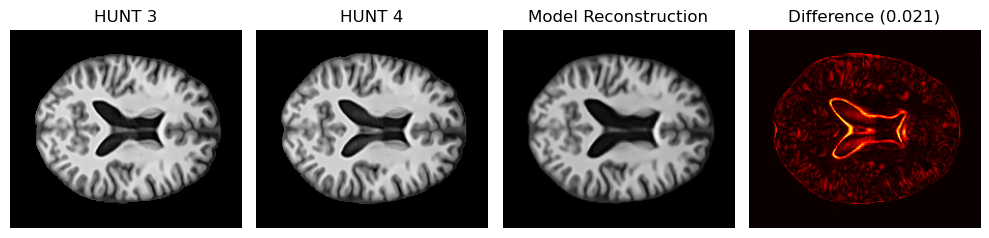

In [11]:
for snapshot in snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [13]:
# Save the final model to /out directory
output_dir = "out/mpgan_3d"
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, "3d_mpgan_D_3.pt")
torch.save(D.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to out/mpgan_3d/3d_mpgan_D_3.pt
